In [1]:
# import packages
from Equipments import BNC575, Weeder, SR400, MCBOX, Andor, Agilent, ThorlabsPM
from Equipments.MCBOX import generate_test_voltages
from DataProcessing.Plot import PlotSaver
import numpy as np
import pyvisa
import time
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

ModuleNotFoundError: No module named 'Equipments'

In [2]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::3::INSTR', 'GPIB0::9::INSTR', 'TCPIP0::169.254.110.10::inst0::INSTR', 'USB0::0x1313::0x807B::241023118::0::INSTR')


In [2]:
import pyvisa
import numpy as np
import struct


class LeCroy9354AM:
    def __init__(self, visa_name, timeout=20000):
        rm = pyvisa.ResourceManager()
        self.inst = rm.open_resource(visa_name)
        self.inst.timeout = timeout
        # self.inst.read_termination = "\n"
        # self.inst.write_termination = "\n"
        self.inst.chunk_size = 1024 * 1024

        try:
            print("*IDN ->", self.inst.query("*IDN?"))
        except Exception as e:
            print("*IDN failed:", e)

    def setup_transfer(self):
        self.inst.write("CHDR OFF")
        self.inst.write("CFMT DEF9,WORD,BIN")
        self.inst.write("WFSU SP,1,NP,0,FP,1,SN,0")

    def _read_ieee_block_precise(self, cmd):
        # print("Sending:", cmd)

        # old_term = self.inst.read_termination
        # self.inst.read_termination = None

        # try:
        self.inst.write(cmd)

        prefix = b""
        while True:
            ch = self.inst.read_bytes(1)
            prefix += ch
            if ch == b"#":
                break

        n_digits = int(self.inst.read_bytes(1).decode())
        len_bytes = self.inst.read_bytes(n_digits)
        n_bytes = int(len_bytes.decode())

        payload = self.inst.read_bytes(n_bytes)

        try:
            self.inst.read_bytes(1, break_on_termchar=False)
        except Exception:
            pass

        # print("Prefix before #:", prefix[:-1])
        # print("Payload length:", len(payload))
        # print("Payload head:", payload[:80])

        return prefix, payload

        # finally:
        #     self.inst.read_termination = old_term

    def read_descriptor(self, channel="C1"):
        _, payload = self._read_ieee_block_precise(f"{channel}:WF? DESC")
        return payload

    def readout_raw(self, channel="C1"):
        _, payload = self._read_ieee_block_precise(f"{channel}:WF? DAT1")
        return payload

    def readout(self, channel="C1", dtype="<i2"):
        payload = self.readout_raw(channel)

        if len(payload) == 0:
            return np.array([], dtype=np.dtype(dtype))

        itemsize = np.dtype(dtype).itemsize
        if len(payload) % itemsize != 0:
            payload = payload[:len(payload) - (len(payload) % itemsize)]

        return np.frombuffer(payload, dtype=np.dtype(dtype))

    def _parse_wavedesc(self, desc):
        if len(desc) < 346:
            raise ValueError(f"Descriptor too short: {len(desc)} bytes")

        def read_int16(offset, endian="<"):
            return struct.unpack(endian + "h", desc[offset:offset+2])[0]

        def read_int32(offset, endian="<"):
            return struct.unpack(endian + "i", desc[offset:offset+4])[0]

        def read_float32(offset, endian="<"):
            return struct.unpack(endian + "f", desc[offset:offset+4])[0]

        def read_float64(offset, endian="<"):
            return struct.unpack(endian + "d", desc[offset:offset+8])[0]

        def read_string(offset, length):
            raw = desc[offset:offset+length]
            return raw.split(b"\x00", 1)[0].decode(errors="ignore").strip()

        # COMM_ORDER decides endianness of numeric fields
        # 0 = HIFIRST (big-endian), 1 = LOFIRST (little-endian)
        comm_order_le = struct.unpack("<h", desc[34:36])[0]
        if comm_order_le == 1:
            endian = "<"
        elif comm_order_le == 0:
            endian = ">"
        else:
            # fallback
            endian = "<"

        info = {}
        info["descriptor_name"]   = read_string(0, 16)
        info["template_name"]     = read_string(16, 16)
        info["comm_type"]         = read_int16(32, endian)
        info["comm_order"]        = read_int16(34, endian)
        info["wave_descriptor"]   = read_int32(36, endian)
        info["user_text"]         = read_int32(40, endian)
        info["trigtime_array"]    = read_int32(48, endian)
        info["ris_time_array"]    = read_int32(52, endian)
        info["wave_array_1"]      = read_int32(60, endian)
        info["wave_array_count"]  = read_int32(116, endian)
        info["pnts_per_screen"]   = read_int32(120, endian)
        info["first_valid_pnt"]   = read_int32(124, endian)
        info["last_valid_pnt"]    = read_int32(128, endian)
        info["first_point"]       = read_int32(132, endian)
        info["sparsing_factor"]   = read_int32(136, endian)
        info["subarray_count"]    = read_int32(144, endian)
        info["vertical_gain"]     = read_float32(156, endian)
        info["vertical_offset"]   = read_float32(160, endian)
        info["max_value"]         = read_float32(164, endian)
        info["min_value"]         = read_float32(168, endian)
        info["horizontal_interval"] = read_float32(176, endian)
        info["horizontal_offset"] = read_float64(180, endian)
        info["vertical_unit"]     = read_string(196, 48)
        info["horizontal_unit"]   = read_string(244, 48)
        info["instrument_name"]   = read_string(76, 16)
        info["trace_label"]       = read_string(96, 16)
        info["wave_source"]       = read_int16(344, endian)

        return info

    def read_waveform(self, channel="C1"):
        desc = self.read_descriptor(channel)
        info = self._parse_wavedesc(desc)

        # Determine sample dtype from descriptor COMM_TYPE
        # 0 = byte, 1 = word
        comm_type = info["comm_type"]
        comm_order = info["comm_order"]

        if comm_type == 0:
            dtype = np.int8
        elif comm_type == 1:
            if comm_order == 1:
                dtype = np.dtype("<i2")
            else:
                dtype = np.dtype(">i2")
        else:
            raise ValueError(f"Unsupported COMM_TYPE: {comm_type}")

        raw = self.readout_raw(channel)

        if len(raw) == 0:
            return np.array([]), np.array([]), info

        itemsize = np.dtype(dtype).itemsize
        if len(raw) % itemsize != 0:
            raw = raw[:len(raw) - (len(raw) % itemsize)]

        adc = np.frombuffer(raw, dtype=dtype)

        # Convert ADC codes to volts
        v = info["vertical_gain"] * adc - info["vertical_offset"]

        # Build time axis
        dt = info["horizontal_interval"]
        t0 = info["horizontal_offset"]
        t = t0 + np.arange(len(v)) * dt

        return t, v, info

    def close(self):
        self.inst.close()

In [3]:
lecroy = LeCroy9354AM("GPIB0::3::INSTR")
# print("-"*60)
# lecroy.setup_transfer()
# test = lecroy.read_descriptor()
# print("-"*60)
t, v, info = lecroy.read_waveform("C1")

print("number of points:", len(v))
print("first 10 t:", t[:10])
print("first 10 v:", v[:10])
print("dt:", info["horizontal_interval"])
print("vertical gain:", info["vertical_gain"])
print("vertical offset:", info["vertical_offset"])
print("x unit:", info["horizontal_unit"])
print("y unit:", info["vertical_unit"])

lecroy.close()

*IDN -> *IDN LECROY,9354AM,935403739,08.2.1

number of points: 50002
first 10 t: [-1.000028e-05 -9.999280e-06 -9.998280e-06 -9.997280e-06 -9.996280e-06
 -9.995280e-06 -9.994280e-06 -9.993280e-06 -9.992280e-06 -9.991280e-06]
first 10 v: [-0.01075 -0.01075 -0.017   -0.0045  -0.01075 -0.017   -0.017   -0.01075
 -0.017   -0.01075]
dt: 9.999999717180685e-10
vertical gain: 2.441406286379788e-05
vertical offset: -0.00800000037997961
x unit: S
y unit: V


*IDN -> LECROY,9354AM,935403739,08.2.1



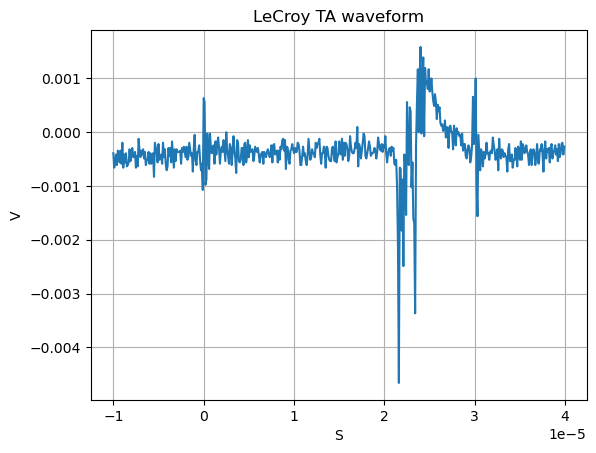

In [6]:
import matplotlib.pyplot as plt

lecroy = LeCroy9354AM("GPIB0::3::INSTR")
lecroy.setup_transfer()

t, v, info = lecroy.read_waveform("TA")
lecroy.close()

plt.plot(t, v)
plt.xlabel(info["horizontal_unit"] or "s")
plt.ylabel(info["vertical_unit"] or "V")
plt.title("LeCroy TA waveform")
plt.grid(True)
plt.show()